In [6]:
from torch_geometric.datasets import TUDataset
from torch_geometric.utils import to_networkx

import networkx as nx
import matplotlib.pyplot as plt

import numpy as np

dataset = TUDataset("./datasets","MUTAG",use_node_attr=True,use_edge_attr=True)
print(dataset)
graphs = [to_networkx(g, node_attrs=["x"],edge_attrs=["edge_attr"],to_undirected=True, remove_self_loops=True) for g in dataset]
y = dataset.y


MUTAG(188)


In [7]:
graphs[0].nodes(data=True)

NodeDataView({0: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 1: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 2: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 3: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 4: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 5: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 6: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 7: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 8: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 9: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 10: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 11: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 12: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 13: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 14: {'x': [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 15: {'x': [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]}, 16: {'x': [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]}})

Node labels:

  0  C
  1  N
  2  O
  3  F
  4  I
  5  Cl
  6  Br

Edge labels:

  0  aromatic
  1  single
  2  double
  3  triple


In [8]:
type(graphs[0].nodes(data=True)[0]['x'])
def convert_node_attr(l):
    attr_table = {0:'C',1:'N',2:'O',3:'F',4:'I',5:'Cl',6:'Br'}
    idx = np.argmax(l)
    return attr_table[idx]
 

In [9]:
   
for g in graphs:
    new_values = {n:convert_node_attr(attr['x']) for n,attr in g.nodes(data=True)}
    nx.set_node_attributes(g, name='atom', values=new_values)

  

In [10]:
graphs[0].nodes(data=True)[13]

{'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}

In [11]:
from gklearn.kernels import PathUpToH

# Initailize parameters for graph kernel computation.
kernel_options = {'depth': 3,'k_func': 'MinMax','compute_method': 'trie'}

# Initialize graph kernel.
graph_kernel = PathUpToH(node_labels=['atom'], # list of node label names.
						 #ds_infos=dataset.get_dataset_infos(keys=['directed']), # dataset information required for computation.
						 **kernel_options, # options for computation.
						 )

print('done.')

import multiprocessing
import matplotlib.pyplot as plt

# Compute Gram matrix.
gram_matrix, run_time = graph_kernel.compute(graphs)
# Print results.

done.
getting paths: 188it [00:00, 500.12it/s]
Computing kernels: 17766it [00:01, 9677.89it/s] 
Gram matrix of size 188 built in 2.5665345191955566 seconds.


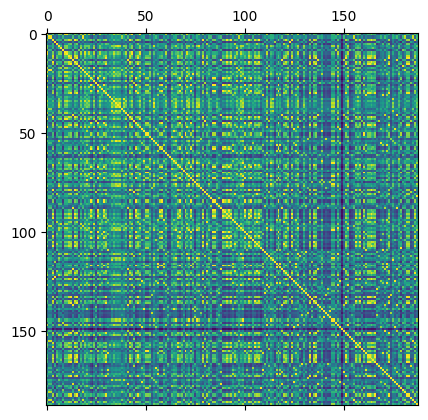

In [12]:
%matplotlib inline 
plt.matshow(gram_matrix)


In [13]:
from sklearn.model_selection import train_test_split
